In [1]:
import torch
import sklearn
import skimage
import torchvision

print("Torch OK:", torch.__version__)
print("Sklearn OK:", sklearn.__version__)
print("Skimage OK:", skimage.__version__)
print("Torchvision OK:", torchvision.__version__)


Torch OK: 2.9.1
Sklearn OK: 1.8.0
Skimage OK: 0.26.0
Torchvision OK: 0.24.1


(np.float64(-0.5), np.float64(149.5), np.float64(149.5), np.float64(-0.5))

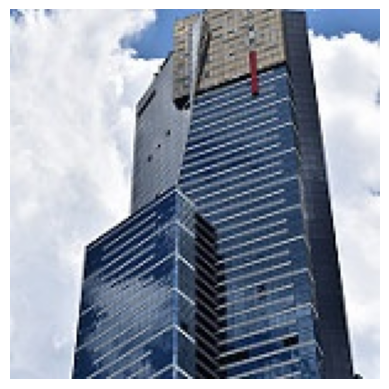

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/Users/udyadityadeo/MacOS/PGM/ML/intel-classification/data/test/buildings/20057.jpg")
plt.imshow(img)
plt.axis('off')


In [3]:
import os
import numpy as np
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
base_dir = "/Users/udyadityadeo/MacOS/PGM/ML/intel-classification/data/train"
classes = [c for c in os.listdir(base_dir) if not c.startswith('.')]
print("Classes:", classes)


Classes: ['forest', 'buildings', 'glacier', 'street', 'mountain', 'sea']


In [5]:
def extract_hog_features(img_path):
    img = imread(img_path)
    img_gray = rgb2gray(img)
    img_gray = resize(img_gray)
    features = hog(
        img_gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )
    return features


In [6]:
'''listing classes of images'''

base_dir = "/Users/udyadityadeo/MacOS/PGM/ML/intel-classification/data/train"
classes = [c for c in os.listdir(base_dir) if not c.startswith('.')]

target_size = (150, 150)
badimages = []

for label, cls in enumerate(classes):
    folder = os.path.join(base_dir, cls)
    print(f"Checking class: {cls}")

    for fname in os.listdir(folder):

        if fname.startswith('.'):
            continue

        fpath = os.path.join(folder, fname)

        try:
            img = imread(fpath)
            h, w = img.shape[:2]

            if (h, w) != target_size:
                badimages.append((fpath, img.shape))
        except Exception as e:
            print(f"Error reading: ", {fpath}, "->", e)
                  


Checking class: forest
Checking class: buildings
Checking class: glacier
Checking class: street
Checking class: mountain
Checking class: sea


In [12]:
'''error check as initial code ran into array error
precisely :ValueError: setting an array element with a sequence.
The requested array has an inhomogeneous shape after 1 
dimensions. The detected shape was (14034,) + 
inhomogeneous part. '''
X = []
y = []
for label, cls in enumerate(classes):
    folder = os.path.join(base_dir, cls)
    print(f"Processing: {cls}")

    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)

        try:
            feat = extract_hog_features(fpath)
            X.append(feat)
            y.append(label)

            if len(feat) != 2916:  # expected length for 150x150 HOG
                print("INCONSISTENT FEATURE:", fpath, "-> length:", len(feat))

        except Exception as e:
            print("FAILED:", fpath, "->", e)

Processing: forest
INCONSISTENT FEATURE: /Users/udyadityadeo/MacOS/PGM/ML/intel-classification/data/train/forest/5109.jpg -> length: 2304
INCONSISTENT FEATURE: /Users/udyadityadeo/MacOS/PGM/ML/intel-classification/data/train/forest/14621.jpg -> length: 2304
INCONSISTENT FEATURE: /Users/udyadityadeo/MacOS/PGM/ML/intel-classification/data/train/forest/6366.jpg -> length: 2304
INCONSISTENT FEATURE: /Users/udyadityadeo/MacOS/PGM/ML/intel-classification/data/train/forest/4565.jpg -> length: 2304
INCONSISTENT FEATURE: /Users/udyadityadeo/MacOS/PGM/ML/intel-classification/data/train/forest/17472.jpg -> length: 2304
INCONSISTENT FEATURE: /Users/udyadityadeo/MacOS/PGM/ML/intel-classification/data/train/forest/15517.jpg -> length: 2304
INCONSISTENT FEATURE: /Users/udyadityadeo/MacOS/PGM/ML/intel-classification/data/train/forest/14609.jpg -> length: 2304
INCONSISTENT FEATURE: /Users/udyadityadeo/MacOS/PGM/ML/intel-classification/data/train/forest/16778.jpg -> length: 2304
INCONSISTENT FEATURE: /U

In [13]:
'''resizing images, some were 17xx, others mostly 2304,'''
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
import numpy as np
from skimage.feature import hog

def extract_hog_features(img_path):
    img = imread(img_path)

    # 1. Fix grayscale images (H x W)
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)

    # 2. Fix RGBA (H x W x 4)
    if img.shape[-1] == 4:
        img = img[:, :, :3]

    # 3. Ensure uniform dtype
    img = img.astype("float32") / 255.0

    # 4. Resize to consistent size
    img = resize(img, (150, 150), anti_aliasing=True)

    # 5. Convert to grayscale
    img_gray = rgb2gray(img)

    # 6. Compute HOG
    features = hog(
        img_gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )
    return features


In [15]:
'''checking unique feature lengths'''
X = []
for cls in classes:
    folder = os.path.join(base_dir, cls)
    for fname in os.listdir(folder):
        if fname.startswith('.'): continue

        fpath = os.path.join(folder, fname)
        feat = extract_hog_features(fpath)
        X.append(feat)

print("Unique feature lengths:", set([len(f) for f in X]))


Unique feature lengths: {2304}


In [16]:
base_dir = "/Users/udyadityadeo/MacOS/PGM/ML/intel-classification/data/train"
classes = [c for c in os.listdir(base_dir) if not c.startswith('.')]

X = []
y = []

for label, cls in enumerate(classes):
    folder = os.path.join(base_dir, cls)
    print(f"Processing class: {cls}")

    for fname in os.listdir(folder):
        if fname.startswith('.'):
            continue

        fpath = os.path.join(folder, fname)

        try:
            feat = extract_hog_features(fpath)
            X.append(feat)
            y.append(label)
        except Exception as e:
            print("Skipping:", fpath, "->", e)


Processing class: forest
Processing class: buildings
Processing class: glacier
Processing class: street
Processing class: mountain
Processing class: sea


In [17]:
X = np.array(X)
y = np.array(y)

In [18]:
print(f"X shape: , {X.shape} and y shape: {y.shape}")

X shape: , (14034, 2304) and y shape: (14034,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y , test_size=0.2, random_state=42, stratify=y
)

In [20]:
print("Training SVM...")
svm_clf = SVC(kernel='linear')
svm_clf.fit(X_train, y_train)

svm_pred = svm_clf.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred, target_names=classes))


Training SVM...
SVM Accuracy: 0.6897043106519416
              precision    recall  f1-score   support

      forest       0.84      0.92      0.88       454
   buildings       0.72      0.74      0.73       438
     glacier       0.55      0.58      0.56       481
      street       0.81      0.78      0.79       476
    mountain       0.54      0.52      0.53       503
         sea       0.69      0.63      0.66       455

    accuracy                           0.69      2807
   macro avg       0.69      0.69      0.69      2807
weighted avg       0.69      0.69      0.69      2807



In [21]:
for label, cls in enumerate(classes):
    print(f"Label: {label} , Cls: {cls} ")

Label: 0 , Cls: forest 
Label: 1 , Cls: buildings 
Label: 2 , Cls: glacier 
Label: 3 , Cls: street 
Label: 4 , Cls: mountain 
Label: 5 , Cls: sea 


In [22]:
print("\nTraining Random Forest...")
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)

rf_pred = rf_clf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred, target_names=classes))



Training Random Forest...
RF Accuracy: 0.7125044531528322
              precision    recall  f1-score   support

      forest       0.89      0.94      0.91       454
   buildings       0.76      0.69      0.73       438
     glacier       0.57      0.65      0.61       481
      street       0.79      0.82      0.80       476
    mountain       0.59      0.53      0.56       503
         sea       0.70      0.65      0.67       455

    accuracy                           0.71      2807
   macro avg       0.72      0.72      0.71      2807
weighted avg       0.71      0.71      0.71      2807



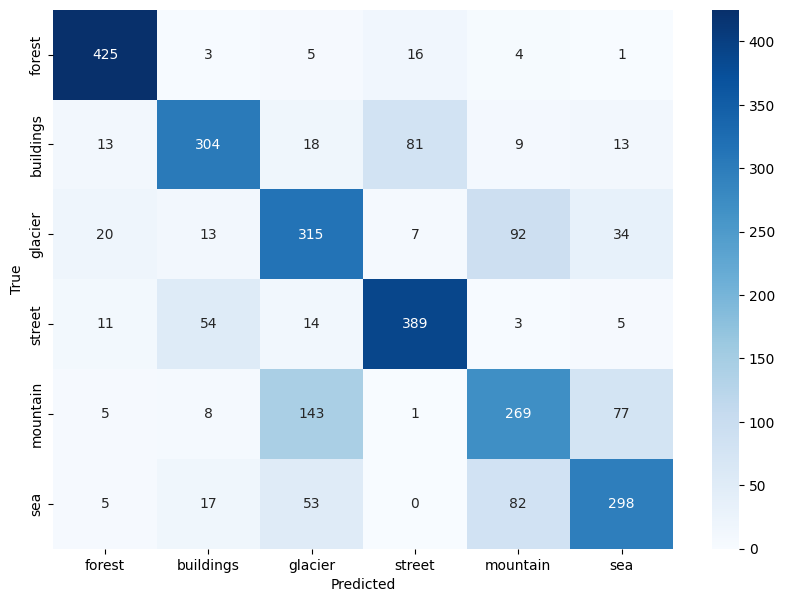

In [23]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


# DecisionTreeClassifier

In [24]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", np.unique(y))


X shape: (14034, 2304)
y shape: (14034,)
Classes: [0 1 2 3 4 5]


In [25]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [28]:
dt = DecisionTreeClassifier(
    max_depth=5,        # keep shallow for interpretability
    random_state=42
)

dt.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [29]:
y_pred = dt.predict(X_test)


#### Evaluation

In [30]:
acc = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", acc)


Decision Tree Accuracy: 0.4713216957605985


In [31]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.78      0.67      0.72       454
           1       0.53      0.34      0.42       438
           2       0.27      0.23      0.25       481
           3       0.47      0.60      0.53       476
           4       0.37      0.53      0.44       503
           5       0.52      0.44      0.48       455

    accuracy                           0.47      2807
   macro avg       0.49      0.47      0.47      2807
weighted avg       0.49      0.47      0.47      2807



In [32]:
print(confusion_matrix(y_test, y_pred))


[[304   7  33  96  14   0]
 [ 22 150  64 121  49  32]
 [ 19  27 112  52 218  53]
 [ 36  66  53 287  26   8]
 [  5  16  81  37 269  95]
 [  2  18  66  24 144 201]]


In [33]:
from sklearn.tree import export_text

rules = export_text(dt, feature_names=[f"HOG_{i}" for i in range(X.shape[1])])
print(rules)


|--- HOG_305 <= 0.12
|   |--- HOG_1376 <= 0.22
|   |   |--- HOG_1426 <= 0.24
|   |   |   |--- HOG_1566 <= 0.24
|   |   |   |   |--- HOG_809 <= 0.17
|   |   |   |   |   |--- class: 4
|   |   |   |   |--- HOG_809 >  0.17
|   |   |   |   |   |--- class: 3
|   |   |   |--- HOG_1566 >  0.24
|   |   |   |   |--- HOG_1569 <= 0.22
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- HOG_1569 >  0.22
|   |   |   |   |   |--- class: 4
|   |   |--- HOG_1426 >  0.24
|   |   |   |--- HOG_1642 <= 0.25
|   |   |   |   |--- HOG_1090 <= 0.09
|   |   |   |   |   |--- class: 5
|   |   |   |   |--- HOG_1090 >  0.09
|   |   |   |   |   |--- class: 2
|   |   |   |--- HOG_1642 >  0.25
|   |   |   |   |--- HOG_1160 <= 0.08
|   |   |   |   |   |--- class: 5
|   |   |   |   |--- HOG_1160 >  0.08
|   |   |   |   |   |--- class: 5
|   |--- HOG_1376 >  0.22
|   |   |--- HOG_1854 <= 0.23
|   |   |   |--- HOG_828 <= 0.17
|   |   |   |   |--- HOG_1106 <= 0.24
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- H

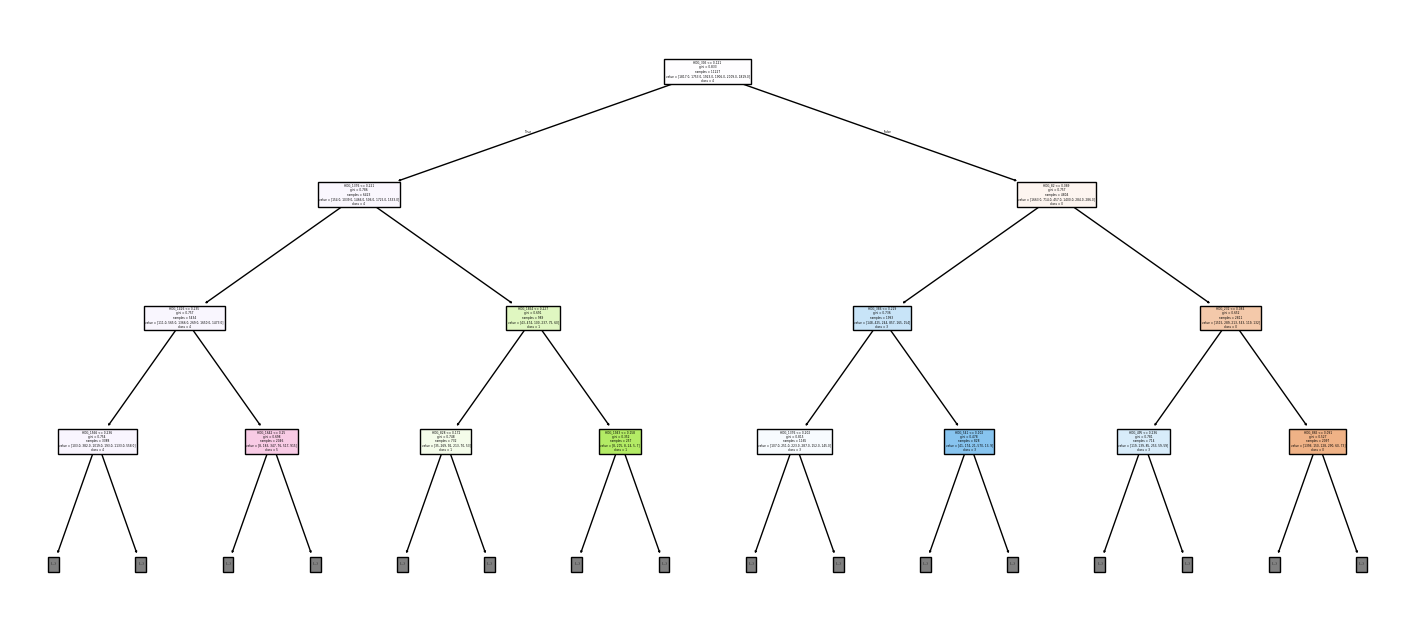

In [34]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18,8))
plot_tree(
    dt,
    max_depth=3,
    filled=True,
    class_names=[str(c) for c in np.unique(y)],
    feature_names=[f"HOG_{i}" for i in range(X.shape[1])]
)
plt.show()
